In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import fetch_openml

from xai_aux import CFCalculations
from xai_aux import simulate_noise_effect

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
credit = pd.read_csv('data/gsc/cs-training.csv').dropna() # very big dataset anyway
credit = credit.sample(frac=0.01)
credit.drop(columns=['Unnamed: 0'],inplace=True)
df = credit.drop(columns=["SeriousDlqin2yrs"])  # Features
y = credit["SeriousDlqin2yrs"].values  # Target variable
cat_feat = []
num_feat = df.columns.to_list()
print(len(df))

1203


In [4]:
n_features = len(df.columns)

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warning

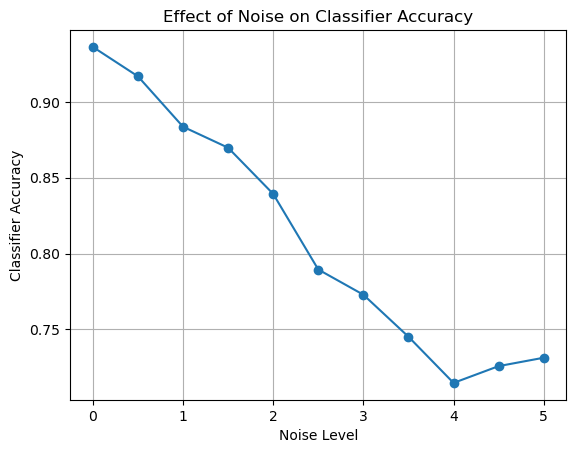

In [5]:
results, datasets = simulate_noise_effect(df, num_feat, cat_feat, y, max_noise=5., step=0.5, min_frequency=None)
noise_levels, accuracies = zip(*results)
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel('Noise Level')
plt.ylabel('Classifier Accuracy')
plt.title('Effect of Noise on Classifier Accuracy')
plt.grid()
plt.show()

In [6]:
def get_polytopes(enc):
    # Get transformed feature names
    feature_names = enc.get_feature_names_out()
    #print("Encoded Feature Names:", feature_names)  # Debugging step

    # Extract number of features per original category
    feature_counts = []
    current_feature = None
    count = 0

    for feature in feature_names:
        original_category = feature.split("_")[0]  # Extract the original category index
        if original_category != current_feature:
            if count > 0:  # Append count for previous category
                feature_counts.append(count)
            current_feature = original_category
            count = 1  # Start counting for new category
        else:
            count += 1
    feature_counts.append(count)  # Append the last count

    # Generate list of lists with sequential numbering
    start = 1
    polytopes = []

    for count in feature_counts:
        polytopes.append(list(range(start, start + count)))
        start += count
    polytopes = [p for p in polytopes if len(p)>1]
    #print("Final polytopes:", polytopes)
    return polytopes

In [7]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X.values, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)
    
    cat_feat2 = [str(i) for i in range(len(cat_feat))]
    enc = OneHotEncoder(drop='first', min_frequency=None, sparse_output=False)
    enc.fit(df_train[cat_feat2])
    X_enc = pd.DataFrame(np.hstack([np.ones((len(df_train),1)), enc.transform(df_train[cat_feat2])]))
    polytopes = get_polytopes(enc)
    
    cf_calc = CFCalculations(
        df_train,
        y_train, 
        df_test.iloc[0:3000], # for speed
        y_test[0:3000],
        [int(i) for i in range(len(cat_feat))],
        [int(i) for i in range(len(cat_feat),len(num_feat)+len(cat_feat))],
        polytopes, 
        do_marg=False,
        do_dice=False,
        min_frequency=None) # no constant assummed
        
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], 
                       columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "cf_calc_gsc.pkl")
    dump(cf_results_dict, "cf_results_dict_gsc.pkl")
    dump(model_results_dict, "model_results_gsc.pkl")
    dump(cfs_good_indices, "cfs_good_indices_gsc.pkl")
    # dump(datasets, "datasets_"+str(mock_data)+"_adult_income.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.


13/13 [==============================] - 0s 540us/step - loss: 0.1984 - accuracy: 0.9471 - precision: 1.0000
TF Test Accuracy: 94.71%
13/13 [==============================] - 0s 440us/step
  Model     Metric     Value
0    lr   accuracy  0.949622
1    lr  precision  0.952173
2   blr   accuracy  0.949622
3   blr  precision  0.952173
4    rf   accuracy  0.937028
5    rf  precision  0.916801
6    tf   accuracy  0.947103
7    tf  precision  0.949908
Working on lr skl
Working on lr blr_mean
Working on lr NICE


Working on lr RL


100%|██████████| 4/4 [00:00<00:00, 180.16it/s]


...

Working on rf NICE


Working on rf RL


100%|██████████| 4/4 [00:00<00:00, 102.83it/s]


Working on tf NICE
Counterfactuals calculated
Checking CFs...
CFs for linear model ok
CFs for bayesian mean linear model ok
CFs for nice linear model not ok
Number or wrong CFs: 397 ( 100.0 %)
CFs for RL linear model not ok
Number or wrong CFs: 397 ( 100.0 %)
CFs for nice rf model ok
CFs for RL rf model not ok
Number or wrong CFs: 6 ( 1.5113350125944585 %)
13/13 [==============================] - 0s 401us/step
CFs for nice tf model ok
CFs checked


/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
